In [1]:
from pathlib import Path

import numpy as np

data_folder = Path("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset")
# data_folder = Path("/Users/persie/PhD_Code/3d_ant_data_rle")

session_list = [6,10,11,13,17,19,20,21,22,23,28,29,30]
obj_ref_frame = [500,180,380,849,459, 59, 842, 24, 93, 176, 2626, 595, 241 ]
prefix = "240905-1616"
skeleton_toml_path = "skeleton.toml"

In [11]:
#Sessions available for CATAR
catar_session = [11, 19, 21, 29, 30]

In [3]:
from src import two_d_loader

sleap = two_d_loader.load_session("/Users/persie/Desktop/Dataset_for_upload/Data/240905-1616/inputs/tracking", session=11, use_polars=False)


Loaded 5 SLEAP slp files.


In [2]:
from src import two_d_loader
catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=11, use_polars=False)

Loaded 1 CATAR csv files.


In [4]:
#find out which rows contain the frame from catar in sleap, compare all tracks and pick the closest one

#do it for a single camera for now
camera = "strawberry"

catar_sub = catar.xs(camera).xs("a_L2", axis=1).loc[0]

sleap_sub = sleap.xs(camera).xs("a_L2", axis=1)

# sleap_sub.loc[catar_sub["frame"]]
annotated_index = catar_sub.index #All the catar annotated frames


In [5]:
matched_frames_sleap = sleap_sub.loc(axis=0)[:, annotated_index].droplevel(level=0)

In [6]:
catar_sub
matched_frames_sleap


,x,y,score
frame,,,
2320,141.548035,455.657562,0.668476
2321,119.617355,445.431152,0.249465
2322,NaN,NaN,0.000000
2323,NaN,NaN,0.000000
2324,NaN,NaN,0.000000
...,...,...,...
3110,NaN,NaN,0.000000
3111,NaN,NaN,0.000000
3112,NaN,NaN,0.000000


In [7]:
diff = catar_sub - matched_frames_sleap

In [8]:
import numpy as np
diff["mag"] = np.sqrt(diff["x"]**2 + diff["y"]**2)

<Axes: xlabel='frame'>

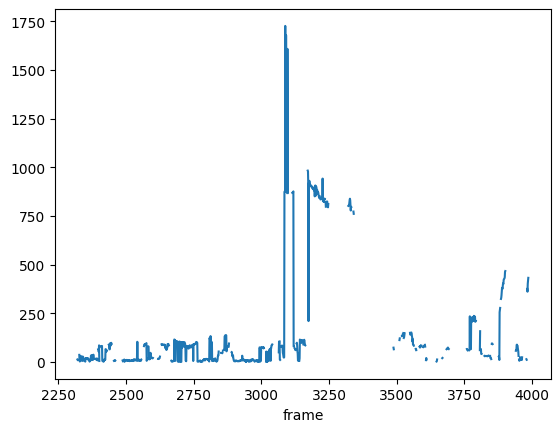

In [9]:
diff.mag.plot()

## Percentage of Frames Annotated with CATAR in 2D
This is just summed across all views

In [159]:
#How many frames are there across all sessions where the keypoint is present
session_data = {}
for catar_session_name in catar_session:
    session_data[catar_session_name] = {}
    #Load the data
    catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=catar_session_name, use_polars=False)

    total_frames = len(catar)
    session_data[catar_session_name]["total_frames"] = total_frames

    print(f"Session {catar_session_name} has {total_frames} frames")

    tracked_left = catar.loc[catar["a_L2", "score"] == 1].index
    session_data[catar_session_name]["tracked_left"] = len(tracked_left)

    print(f"Session {catar_session_name} has {len(tracked_left)} frames where a_L2 is tracked")

    tracked_right = catar.loc[catar["a_R2", "score"] == 1].index
    session_data[catar_session_name]["tracked_right"] = len(tracked_right)

    print(f"Session {catar_session_name} has {len(tracked_right)} frames where a_R2 is tracked")

    # Find instances that repeat in the tracked left and tracked right
    tracked_both = list(set(tracked_left) & set(tracked_right))
    session_data[catar_session_name]["tracked_both"] = len(tracked_both)

    print(f"Session {catar_session_name} has {len(tracked_both)} frames where the a_L2 and a_R2 are tracked")

    #For the tracked both list of tuples, count the number of occurences of each frame

    values, count = np.unique_counts(np.array(tracked_both)[:,2])

    tracked_all_view = np.nonzero(count > 4)
    session_data[catar_session_name]["tracked_all_view"] = len(tracked_all_view[0])
    print(f"Session {catar_session_name} has {len(tracked_all_view[0])} frames where the a_L2 and a_R2 are tracked in all views")


    tracked_two_view = np.nonzero(count > 1)
    session_data[catar_session_name]["tracked_two_view"] = len(tracked_two_view[0])

    print(f"Session {catar_session_name} has {len(tracked_two_view[0])} frames where the a_L2 and a_R2 are tracked in at least 2 views")

    # catar.a_R2.loc[(slice(None), slice(None), [2323])]

    session_data[catar_session_name]["percent_left"] = session_data[catar_session_name]["tracked_left"] / session_data[catar_session_name]["total_frames"] * 100

    session_data[catar_session_name]["percent_right"] = session_data[catar_session_name]["tracked_right"] / session_data[catar_session_name]["total_frames"] * 100

    session_data[catar_session_name]["percent_both"] = session_data[catar_session_name]["tracked_both"] / session_data[catar_session_name]["total_frames"] * 100




Loaded 1 CATAR csv files.
Session 11 has 8395 frames
Session 11 has 4178 frames where a_L2 is tracked
Session 11 has 3439 frames where a_R2 is tracked
Session 11 has 2648 frames where the a_L2 and a_R2 are tracked
Session 11 has 5 frames where the a_L2 and a_R2 are tracked in all views
Session 11 has 927 frames where the a_L2 and a_R2 are tracked in at least 2 views
Loaded 1 CATAR csv files.
Session 19 has 2905 frames
Session 19 has 2005 frames where a_L2 is tracked
Session 19 has 1462 frames where a_R2 is tracked
Session 19 has 1300 frames where the a_L2 and a_R2 are tracked
Session 19 has 9 frames where the a_L2 and a_R2 are tracked in all views
Session 19 has 492 frames where the a_L2 and a_R2 are tracked in at least 2 views
Loaded 1 CATAR csv files.
Session 21 has 3655 frames
Session 21 has 3010 frames where a_L2 is tracked
Session 21 has 2441 frames where a_R2 is tracked
Session 21 has 2378 frames where the a_L2 and a_R2 are tracked
Session 21 has 114 frames where the a_L2 and a_R

In [162]:
#Work out the proportions
total_percents = {}
total_percents["total_frames"] = 0
total_percents["tracked_left"] = 0
total_percents["tracked_right"] = 0
total_percents["tracked_both"] = 0
total_percents["tracked_all_view"] = 0
total_percents["tracked_two_view"] = 0

for catar_session_name in catar_session:
    total_percents["total_frames"] += session_data[catar_session_name]["total_frames"]
    total_percents["tracked_left"] += session_data[catar_session_name]["tracked_left"]
    total_percents["tracked_right"] += session_data[catar_session_name]["tracked_right"]
    total_percents["tracked_both"] += session_data[catar_session_name]["tracked_both"]
    total_percents["tracked_all_view"] += session_data[catar_session_name]["tracked_all_view"]
    total_percents["tracked_two_view"] += session_data[catar_session_name]["tracked_two_view"]


percent_left = total_percents["tracked_left"] / total_percents["total_frames"] * 100

percent_right = total_percents["tracked_right"] / total_percents["total_frames"] * 100

percent_both = total_percents["tracked_both"] / total_percents["total_frames"] * 100

percent_all_view = total_percents["tracked_all_view"] / total_percents["total_frames"] * 100

percent_two_view = total_percents["tracked_two_view"] / total_percents["total_frames"] * 100

print(f"Total frames: {total_percents['total_frames']}")
print(f"Total frames where left is tracked: {total_percents['tracked_left']}")
print(f"Total frames where right is tracked: {total_percents['tracked_right']}")
print(f"Total frames where both are tracked: {total_percents['tracked_both']}")
print(f"Total frames where both are tracked in all views: {total_percents['tracked_all_view']}")
print(f"Total frames where both are tracked in at least 2 views: {total_percents['tracked_two_view']}")

print(f"Percent left : {percent_left}")
print(f"Percent right : {percent_right}")
print(f"Percent both : {percent_both}")
print(f"Percent all views : {percent_all_view}")
print(f"Percent two views : {percent_two_view}")


Total frames: 31865
Total frames where left is tracked: 19966
Total frames where right is tracked: 18320
Total frames where both are tracked: 14113
Total frames where both are tracked in all views: 295
Total frames where both are tracked in at least 2 views: 4637
Percent left : 62.65808881217637
Percent right : 57.49254668131179
Percent both : 44.28997332496469
Percent all views : 0.9257806370626078
Percent two views : 14.55201631884513
